# Regional composite eddies: S, U and D
Pool **S1+S2 → S, U1+U2 → U, D1+D2 → D** at the eddy-day level **before** reconstruction, centre averaging, and whole-eddy bootstrap uncertainty. `Subregion` retains the original six labels. This does not average two precomputed regional means or give unequal-sized subregions equal weight.

The main visual comparisons are four **2×3 figures**: shallow on the top row, deep on the bottom, and S/U/D across columns. First show pooled-Rossby tilt; then overlay low/high |Ro| with **low solid and high dashed**, keeping AE red and CE blue. Repeat both for tilt divided by each day's surface Rc.

There are 6 whole-region AE/CE baselines, 12 shallow/deep AE/CE groups with all Rossby numbers pooled, and 24 shallow/deep/low-high/AE-CE groups. Days with unknown Ro enter the pooled groups but not low/high groups. Every eddy-day is reconstructed once and accumulated into its relevant groups.

Shallow/deep uses deepest valid fitted depth ≤/>1,000 m; low/high uses |surface Ro| < / ≥0.5. Group labels are day-specific, and tracks can cross regions/classes. Existing tilt measurements, PV dominance, shelf class and stratification do not filter the population. Tilt is surface-to-depth displacement of the mean constituent centre in geographic east/north. Velocities remain in native model-grid axes; geographic sections rotate both sampling points and vectors.

Uncertainty resamples whole eddies while retaining equal-day weighting. Variance describes member spread; confidence intervals describe uncertainty in the mean, excluding ESP fit error. Sparse depths are flagged without discarding otherwise valid days. Exact fitted depths are used with no vertical interpolation.


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
HERE=Path.cwd().resolve()
ANALYSIS=next((p for p in (HERE,*HERE.parents) if (p/'seacofs_tilt_tools.py').exists()),None)
if ANALYSIS is None: raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or a subfolder')
WORK=ANALYSIS/'esp_population_composites'
DATASET_SRC=ANALYSIS.parent/'seacofs_eddy_dataset_modular'/'src'
ESP_ROOT=Path('/home/z5297792/ESP_zonodo')
for p in (ANALYSIS,WORK,DATASET_SRC,ESP_ROOT):
    if str(p) not in sys.path: sys.path.insert(0,str(p))
import functions as esp
import seacofs_tilt_tools as tilt
import planetary_composite_tools as pct
import composite_comparison_tools as ccomp
import regional_composite_tools as rct
pd.set_option('display.max_columns',60)


In [2]:
REGION_GROUPS=list(rct.REGION_GROUPS)  # S, U, D
# Population/analysis controls: none of the diagnostics below adds a PV/shelf/N2 filter.
SPLIT_DEPTH_M=1000.
ROSSBY_SPLIT=.5
DOMINANCE_FACTOR=2.
SHELF_LON=154.75
ELLIPSE_FRAC=1.
USE_PV_CACHE=True
BOOTSTRAPS=500
SEED=731
MIN_PLOT_EDDIES=2
SPARSE_EDDIES=20  # visual warning only, not an input filter
WIDTH_KM,RES_KM=400.,10.
RUN_VELOCITY_COMPOSITES=True
RUN_COMPOSITE_FITS=True
SUMMARY_TARGET_DEPTH_M=850.
DEPTH_TOLERANCE_M=100.
MATCH_SHALLOW_TARGETS_M=[200.,500.,850.]
MATCH_DEEP_TARGETS_M=[200.,500.,850.,1500.]
# Load existing corrected N2 diagnostics if available; never compute a new N2 cache here.
LOAD_STRATIFICATION_DIAGNOSTICS=True
N2_CACHE=Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/tilt_mechanisms/n2_eddy_day_v4_potential_density_core.parquet')
MIN_N2_CORE_VALID_FRACTION=.80


In [3]:
paths=tilt.Paths()
grid=tilt.load_grid(paths.grid,paths.z_r)
surface,_=tilt.load_tilt_tables(paths,add_regions=True,grid=grid)
surface = tilt.add_pv_gradient_terms(
    surface,
    grid,
    core_mean=True,
    frac=ELLIPSE_FRAC,
    surface_method="esp_gaussian",
    averaging="nonlinear",
    use_max_abs_w=True,
    max_depth_m=1000,
    use_cache=USE_PV_CACHE,
)
# Refresh the established six labels even if PV was loaded from its saved table.
surface=tilt.add_region_labels(surface,grid)
surface=rct.combine_region_labels(surface)
vertical=tilt.load_vert(paths)
if LOAD_STRATIFICATION_DIAGNOSTICS and N2_CACHE.exists():
    sys.path.insert(0,str(ANALYSIS/'tilt_mechanisms'))
    import mechanism_tools as mech
    n2=mech.load_stratification_cache(N2_CACHE)
    fields=['Eddy','Day']+[c for c in n2 if c in [
        'N2_200m_core_s2','N2_500m_core_s2','N2_200m_core_valid_fraction','N2_500m_core_valid_fraction']]
    surface=surface.merge(n2[fields],on=['Eddy','Day'],how='left',validate='one_to_one')
    for z in [200,500]:
        coverage=f'N2_{z}m_core_valid_fraction'
        surface[f'N2_{z}m_s2']=surface[f'N2_{z}m_core_s2'].where(
            surface[coverage].ge(MIN_N2_CORE_VALID_FRACTION)) if coverage in surface else np.nan
    print('Loaded existing N2 cache; insufficient/unknown coverage stays unavailable.')
else:
    print('Stratification diagnostics unavailable or disabled; all other analysis continues.')
selection_audit,profile_audit,centred_profiles=rct.prepare_population(surface,vertical,
    split_depth=SPLIT_DEPTH_M,ro_split=ROSSBY_SPLIT,dominance_factor=DOMINANCE_FACTOR,shelf_lon=SHELF_LON,regions=REGION_GROUPS)
centred_profiles=rct.bottom_audit(centred_profiles,grid)
display(selection_audit.groupby('selection_status').size().rename('eddy_days'))
display(profile_audit.groupby(['Region','Cyc','profile_status']).size().rename('eddy_days'))


Loaded existing N2 cache; insufficient/unknown coverage stays unavailable.


selection_status
outside named regions         2
selected                 127424
Name: eddy_days, dtype: int64

Region  Cyc  profile_status      
D       AE   no valid surface fit     2050
             usable                  34502
        CE   no valid surface fit     1923
             usable                  24362
S       AE   no valid surface fit      462
             usable                   8407
        CE   no valid surface fit      657
             usable                  13295
U       AE   no valid surface fit      885
             usable                  18644
        CE   no valid surface fit      904
             usable                  21333
Name: eddy_days, dtype: int64

## Population inventory before reconstruction
Counts below include all 42 slots, including zero-count groups. Unknown Rossby numbers are reported in baselines. The same eddy may appear in several rows, so unique-eddy counts must not be summed across groups.

Local bottom checks use the original fitted centre at every depth and the nearest wet model-cell bathymetry. They flag below-bottom fitted levels and unavailable/out-of-domain checks; they **do not filter** the profiles or apply a bathymetric mask to the idealised ESP velocities. Bottom depth at the centre alone does not guarantee support across the entire eddy footprint.


,Region,cohort,Ro_class,Cyc,eddy_days,eddies,unknown_Ro_days,median_max_depth_m,median_abs_Ro,median_surface_Rc_km
0,S,all,all,AE,8407,401,0,1128.898331,0.417382,69.432504
1,S,all,all,CE,13295,564,0,1971.212518,0.442327,56.627040
2,U,all,all,AE,18644,594,0,1128.898331,0.286006,79.446302
3,U,all,all,CE,21333,607,0,1492.971178,0.297227,76.059528
4,D,all,all,AE,34502,880,0,1971.212518,0.264974,77.491786
5,D,all,all,CE,24362,791,0,2568.677466,0.215095,72.084170
6,S,shallow,low,AE,2869,290,0,327.440851,0.325447,50.630123
7,S,shallow,low,CE,2011,345,0,515.416489,0.317466,51.383858
8,S,shallow,high,AE,1103,140,0,407.922192,0.618698,50.303640
9,S,shallow,high,CE,1480,263,0,660.806374,0.728525,42.466236


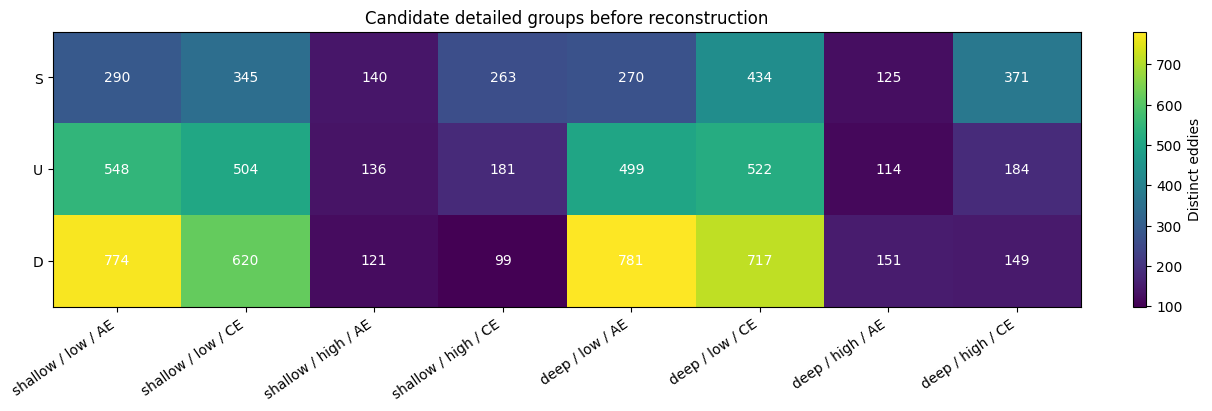

,fitted_levels,checked_levels,below_bottom_fraction
Depth,,,
0.000000,120543,120543,0.000000
5.879627,120543,120543,0.000000
10.725783,120543,120535,0.000000
16.383097,119527,119523,0.000000
22.925581,118927,118922,0.000000
30.444118,118488,118487,0.000000
39.052712,118103,118102,0.000000
48.897638,117700,117695,0.000000
60.170639,117260,117258,0.000000


In [4]:
population_inventory=rct.inventory(profile_audit,regions=REGION_GROUPS,pool_rossby=True)
with pd.option_context('display.max_rows',None): display(population_inventory)
count_matrix=population_inventory.loc[population_inventory.cohort.ne('all') & population_inventory.Ro_class.ne('all')].pivot(
    index='Region',columns=['cohort','Ro_class','Cyc'],values='eddies').reindex(REGION_GROUPS)
fig,ax=plt.subplots(figsize=(12,4),constrained_layout=True)
im=ax.imshow(count_matrix.to_numpy(),aspect='auto',cmap='viridis')
ax.set(yticks=np.arange(len(count_matrix)),yticklabels=count_matrix.index,
       xticks=np.arange(len(count_matrix.columns)),xticklabels=[' / '.join(c) for c in count_matrix.columns])
plt.setp(ax.get_xticklabels(),rotation=35,ha='right')
for i in range(len(count_matrix)):
    for j in range(len(count_matrix.columns)):ax.text(j,i,int(count_matrix.iloc[i,j]),ha='center',va='center',color='white')
fig.colorbar(im,ax=ax,label='Distinct eddies');ax.set_title('Candidate detailed groups before reconstruction')
plt.show()
bottom_check=centred_profiles.groupby('Depth').agg(
    fitted_levels=('Day','size'),checked_levels=('below_local_bottom','count'),
    below_bottom_fraction=('below_local_bottom','mean'))
display(bottom_check)


## Construct each unique eddy-day once
All fields use paired finite u/v values and per-cell denominators. A contributing centre is retained only if the day supplied finite velocity somewhere at that level. With velocity reconstruction disabled, the mode is explicitly centre-only and no composite ESP fit or velocity plot is produced. Profile validity is unchanged from the breakdown notebook.

`regional_results[(region, cohort, Ro_class, Cyc)]` is the main container. Baselines use `('all','all')` for cohort and Ro class; pooled depth groups use `('shallow','all')` or `('deep','all')`. For example: `regional_results[('U','deep','high','CE')]`.


In [5]:
a=np.arange(-WIDTH_KM/2,WIDTH_KM/2+RES_KM/2,RES_KM)
X,Y=np.meshgrid(a,a)
regional_results,reconstruction_audit=rct.build_composites(profile_audit,centred_profiles,X,Y,esp,
    grid_angle=grid.angle,velocity=RUN_VELOCITY_COMPOSITES,pool_rossby=True)
if not regional_results:raise ValueError('No contributing regional profiles')
rct.add_statistics(regional_results,n_boot=BOOTSTRAPS,seed=SEED)
centre_stats=rct.table(regional_results)
normalised_centre_stats=rct.table(regional_results,'normalised_stats')
contributor_inventory=pd.DataFrame([
    dict(zip(rct.KEYS,key),eddy_days=len(r['members'][['Eddy','Day']].drop_duplicates()),
         eddies=r['members'].Eddy.nunique(),mode=r['mode']) for key,r in regional_results.items()])
display(reconstruction_audit.groupby('reconstruction_status').size().rename('eddy_days'))
display(contributor_inventory)
print('Groups with contributors:',len(regional_results),'of 42')


Reconstructed 1000 unique eddy-days
Reconstructed 2000 unique eddy-days
Reconstructed 3000 unique eddy-days
Reconstructed 4000 unique eddy-days
Reconstructed 5000 unique eddy-days
Reconstructed 6000 unique eddy-days
Reconstructed 7000 unique eddy-days
Reconstructed 8000 unique eddy-days
Reconstructed 9000 unique eddy-days
Reconstructed 10000 unique eddy-days
Reconstructed 11000 unique eddy-days
Reconstructed 12000 unique eddy-days
Reconstructed 13000 unique eddy-days
Reconstructed 14000 unique eddy-days
Reconstructed 15000 unique eddy-days
Reconstructed 16000 unique eddy-days
Reconstructed 17000 unique eddy-days
Reconstructed 18000 unique eddy-days
Reconstructed 19000 unique eddy-days
Reconstructed 20000 unique eddy-days
Reconstructed 21000 unique eddy-days
Reconstructed 22000 unique eddy-days
Reconstructed 23000 unique eddy-days
Reconstructed 24000 unique eddy-days
Reconstructed 25000 unique eddy-days
Reconstructed 26000 unique eddy-days
Reconstructed 27000 unique eddy-days
Reconstruc

reconstruction_status
included    120543
Name: eddy_days, dtype: int64

,Region,cohort,Ro_class,Cyc,eddy_days,eddies,mode
0,D,all,all,CE,24362,791,finite ESP contributors
1,D,deep,all,CE,18527,735,finite ESP contributors
2,D,deep,low,CE,17677,717,finite ESP contributors
3,D,all,all,AE,34502,880,finite ESP contributors
4,D,deep,all,AE,24613,792,finite ESP contributors
5,D,deep,low,AE,22084,781,finite ESP contributors
6,S,all,all,AE,8407,401,finite ESP contributors
7,S,deep,all,AE,4435,305,finite ESP contributors
8,S,deep,low,AE,2661,270,finite ESP contributors
9,D,shallow,all,CE,5835,647,finite ESP contributors


Groups with contributors: 42 of 42


## Physical displacement: shallow/deep × S/U/D
The first figure pools all Rossby numbers; the second splits low/high using solid/dashed lines. Both plot the norm of the mean constituent displacement in km with pointwise 95% whole-eddy bootstrap intervals. Colours identify AE/CE. Open circles flag fewer than `SPARSE_EDDIES` contributors.

Rows share depth limits within a cohort, and all six panels use a common distance scale within each figure. Group-specific support, mean individual distances and coherence remain in `centre_stats`.


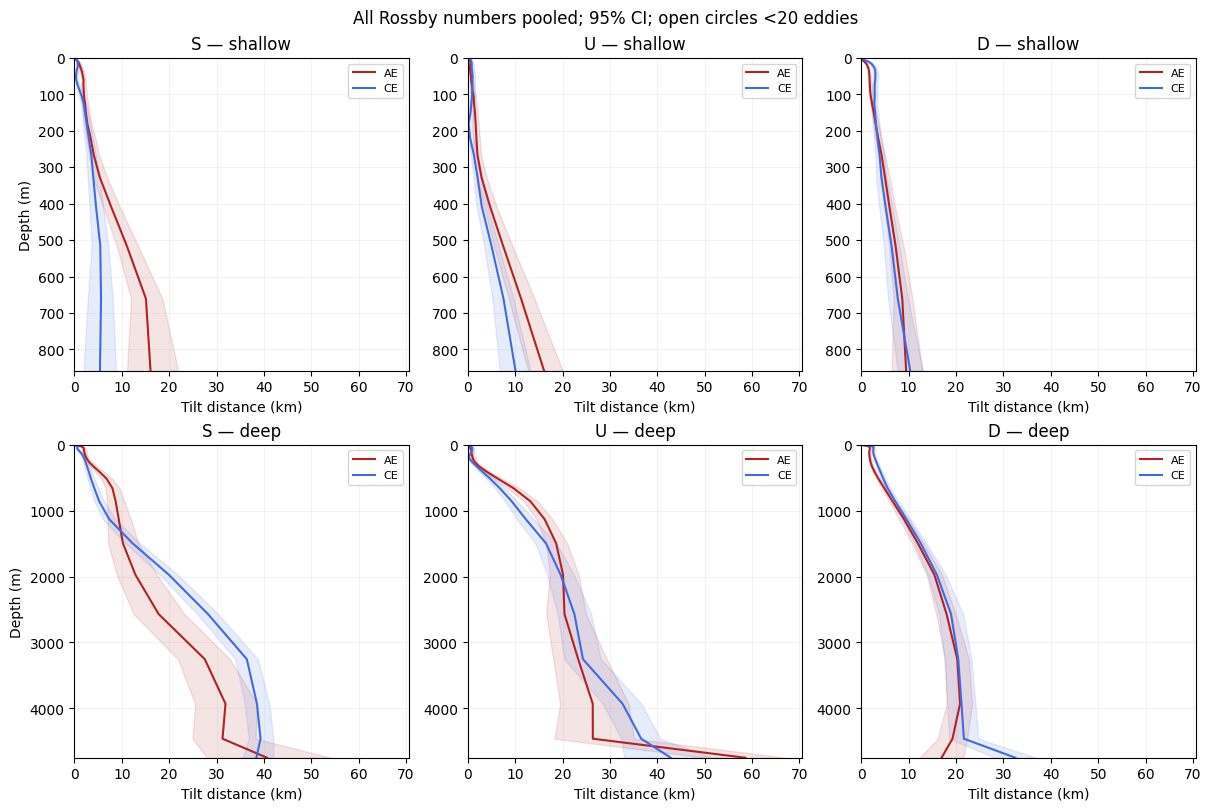

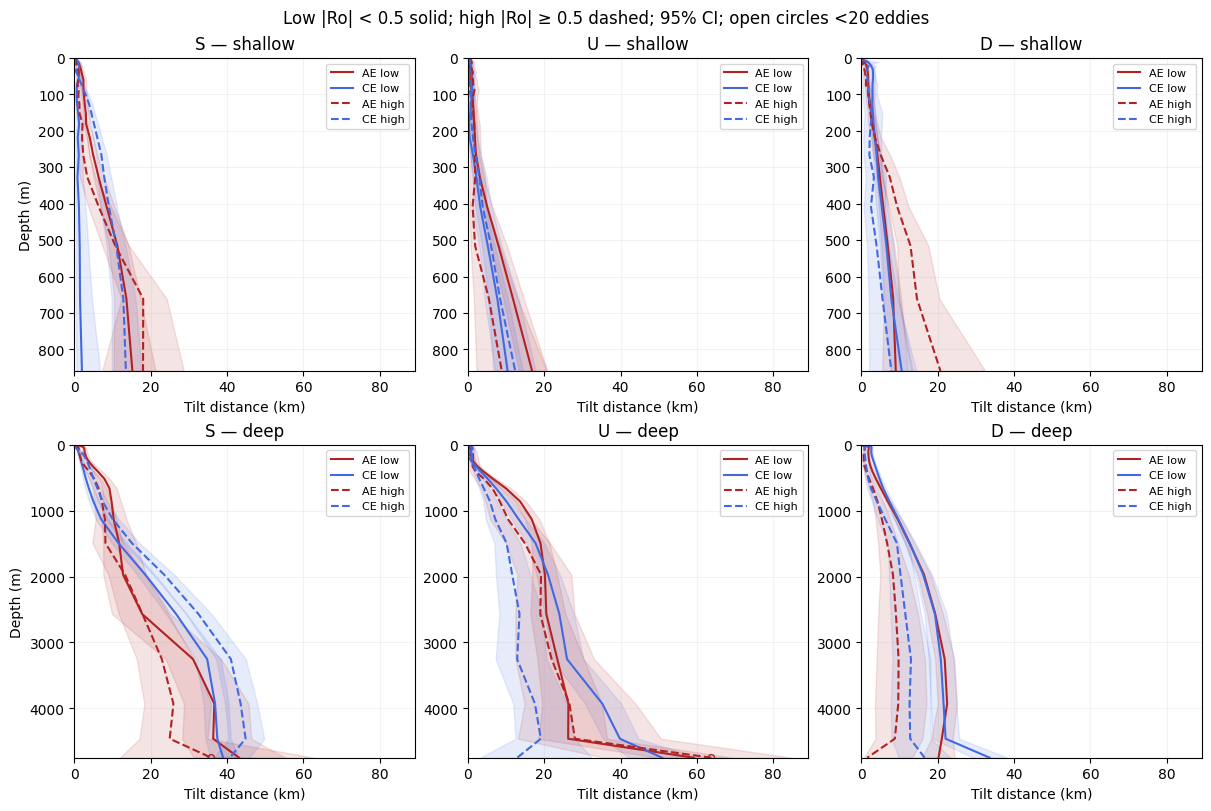

,Region,cohort,Ro_class,Cyc,Depth,n_eddy_days,n_eddies,coherence,bottom_checked_days,below_bottom_fraction
0,D,all,all,CE,0.000000,24362,791,NaN,24362,0.0
1,D,all,all,CE,5.879627,24362,791,0.112636,24362,0.0
2,D,all,all,CE,10.725783,24362,791,0.169852,24361,0.0
3,D,all,all,CE,16.383097,24111,790,0.205079,24111,0.0
4,D,all,all,CE,22.925581,23974,790,0.224881,23974,0.0
...,...,...,...,...,...,...,...,...,...,...
1111,U,shallow,high,CE,327.440851,960,149,0.225695,960,0.0
1112,U,shallow,high,CE,407.922192,851,135,0.231638,851,0.0
1113,U,shallow,high,CE,515.416489,704,128,0.272247,702,0.0
1114,U,shallow,high,CE,660.806374,463,114,0.290589,462,0.0


In [6]:
for split_ro in [False,True]:
    fig,axs=rct.plot_combined_regions(regional_results,split_rossby=split_ro,
        min_eddies=MIN_PLOT_EDDIES,sparse_eddies=SPARSE_EDDIES)
    plt.show()
display(centre_stats[list(rct.KEYS)+['Depth','n_eddy_days','n_eddies','coherence',
                                   'bottom_checked_days','below_bottom_fraction']])


In [7]:
# Change these controls to inspect one region's low/high-Ro differences in detail.
FOCUS_REGION='D'
FOCUS_COHORT='deep'
FOCUS_RO_CLASS='high'
SHOW_FOCUS_DIAGNOSTICS=False
if SHOW_FOCUS_DIAGNOSTICS:
    rct.plot_group_vectors(regional_results,FOCUS_REGION,FOCUS_COHORT,min_eddies=MIN_PLOT_EDDIES)
    plt.show()
    # fig,axs=plt.subplots(1,2,figsize=(10,4),constrained_layout=True)
    # for ro,style in [('low','-'),('high','--')]:
    #     for cyc in ['AE','CE']:
    #         r=regional_results.get((FOCUS_REGION,FOCUS_COHORT,ro,cyc))
    #         if r is None:continue
    #         s=r['stats']
    #         axs[0].plot(s.n_eddies,s.Depth,style,color=rct.COLORS[cyc],label=f'{cyc} {ro}')
    #         axs[1].plot(s.below_bottom_fraction,s.Depth,style,color=rct.COLORS[cyc],label=f'{cyc} {ro}')
    # for ax,label in zip(axs,['Distinct contributing eddies','Fraction of checked centres below local bottom']):
    #     ax.set(xlabel=label,ylabel='Depth (m)');
    #     if ax.lines:ax.legend(); ax.invert_yaxis()
    # plt.show()


## Tilt normalised by each day's surface Rc
Divide each member's east/north displacement by **its own fitted surface Rc before averaging**. Then take the norm of that averaged dimensionless vector and bootstrap over entire eddies. This is not the kilometre composite displacement divided by a mean radius.

Only the centre displacements are normalised. The velocity composites and their full ESP fits remain in physical kilometres and m/s. Each valid surface profile already requires a finite positive Rc. No new size-based selection is introduced.

The following two figures repeat the same S/U/D shallow/deep layout, with and without the Rossby split.


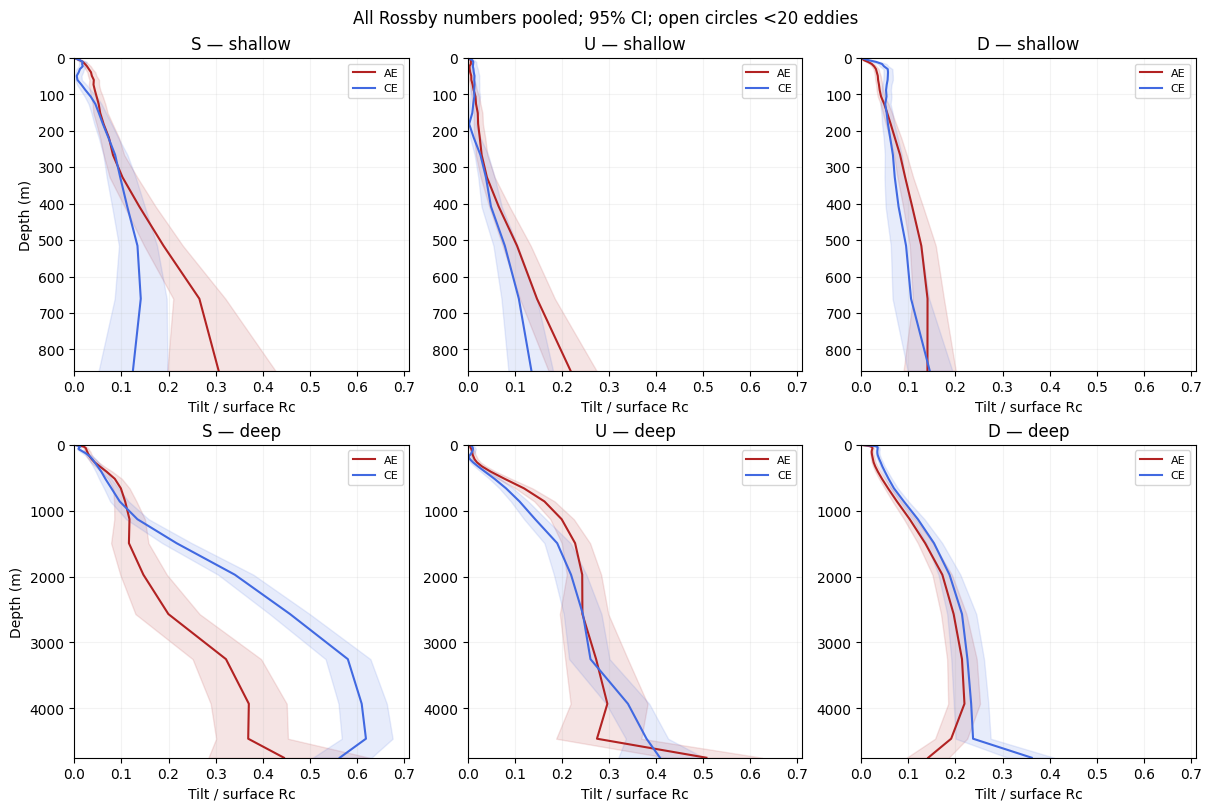

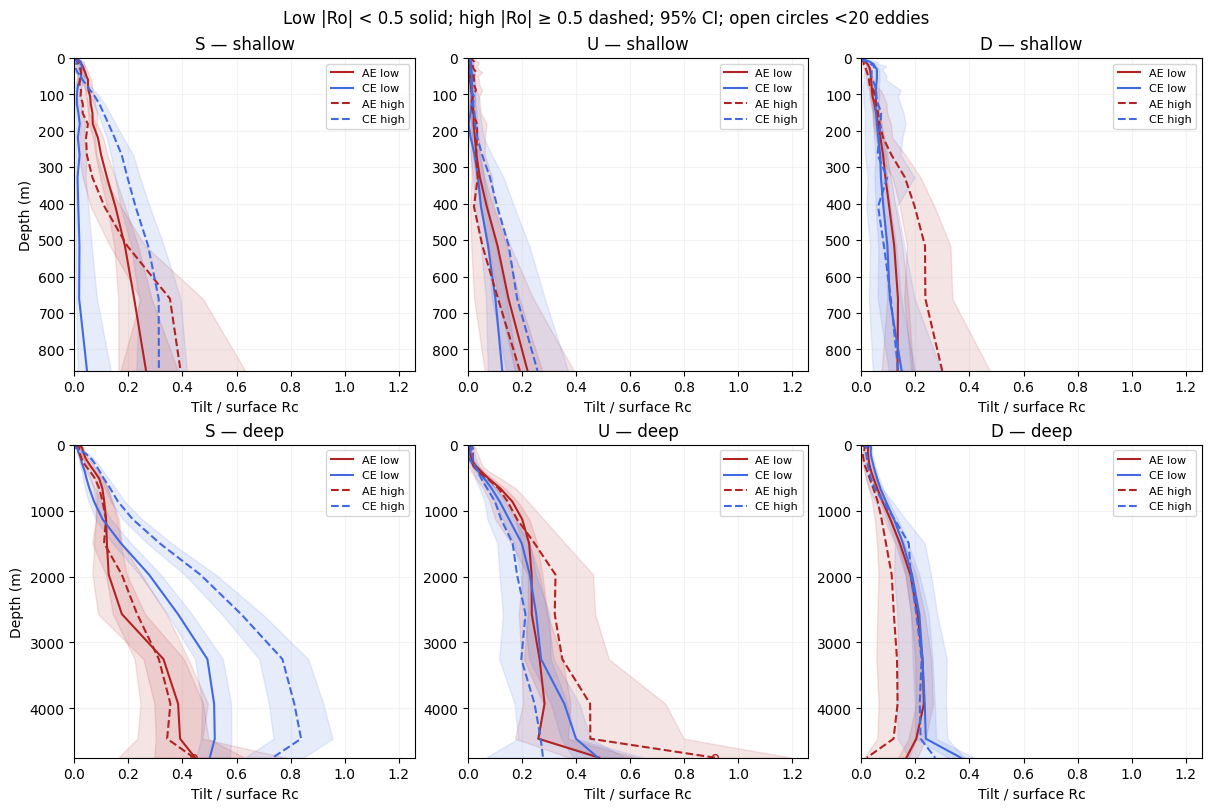

In [8]:
for split_ro in [False,True]:
    fig,axs=rct.plot_combined_regions(regional_results,split_rossby=split_ro,normalised=True,
        min_eddies=MIN_PLOT_EDDIES,sparse_eddies=SPARSE_EDDIES)
    plt.show()


## Summary at one common physical depth
Resolve the requested depth once against the dataset's fitted depth grid. Every group is then assessed at that exact level. A group missing that level stays unavailable; it is never assigned its own nearest depth. Available but sparse rows are labelled. This avoids letting one sparse regional group choose a different reference depth for everyone.


In [9]:
targets=sorted(set([SUMMARY_TARGET_DEPTH_M]+MATCH_SHALLOW_TARGETS_M+MATCH_DEEP_TARGETS_M))
depth_map=rct.resolve_depths(centred_profiles.Depth.unique(),targets,DEPTH_TOLERANCE_M)
display(depth_map)
summary_depth=float(depth_map.set_index('target_m').loc[SUMMARY_TARGET_DEPTH_M,'Depth'])
tilt_summary=rct.summary_at_depth(regional_results,summary_depth,min_eddies=MIN_PLOT_EDDIES)
with pd.option_context('display.max_rows',None):display(tilt_summary)


,target_m,Depth,status
0,200.0,181.264793,ok
1,500.0,515.416489,ok
2,850.0,858.918478,ok
3,1500.0,1492.971178,ok


,Region,cohort,Ro_class,Cyc,Depth,status,distance_km,ci_low,ci_high,distance_Rc,n_eddies,n_eddy_days
0,D,all,all,CE,858.918478,ok,7.356390,6.606874,8.069069,0.093502,751,19743
1,D,deep,all,CE,858.918478,ok,7.172023,6.553014,7.857993,0.090222,735,18527
2,D,deep,low,CE,858.918478,ok,7.341234,6.625417,8.121772,0.091093,717,17677
3,D,all,all,AE,858.918478,ok,6.746854,6.047399,7.476735,0.078903,807,26199
4,D,deep,all,AE,858.918478,ok,6.596400,5.871794,7.290579,0.075571,792,24613
5,D,deep,low,AE,858.918478,ok,6.917875,6.255378,7.638642,0.078159,781,22084
6,S,all,all,AE,858.918478,ok,9.453400,7.631671,11.511800,0.127746,327,4935
7,S,deep,all,AE,858.918478,ok,8.711611,6.863326,10.532403,0.107819,305,4435
8,S,deep,low,AE,858.918478,ok,9.736768,7.440981,12.189058,0.110328,270,2661
9,D,shallow,all,CE,858.918478,ok,10.316133,7.674985,13.004916,0.145321,384,1216


## Fixed-membership sensitivity
Within each detailed group, keep only days present at **every resolved target depth plus the surface**. Shallow and deep groups use separate target lists because shallow profiles cannot reach the deeper targets. Across regions/Rossby/polarity groups, the target list is identical for the same depth cohort.

The matched curves are evaluated only at those target levels, so membership is truly fixed along each plotted curve. The normalised estimator is recomputed on the same matched days. Empty matches and unresolved targets are reported without relaxing the rule. This sensitivity analysis is intentionally selective; the original available-day composites remain the main results.


,Region,cohort,Ro_class,Cyc,matched_days,matched_eddies,required_depths_m,status
0,D,deep,all,CE,16495,718,"0, 181.265, 515.416, 858.918, 1492.97",ok
1,D,deep,low,CE,15754,699,"0, 181.265, 515.416, 858.918, 1492.97",ok
2,D,deep,all,AE,22178,772,"0, 181.265, 515.416, 858.918, 1492.97",ok
3,D,deep,low,AE,19786,760,"0, 181.265, 515.416, 858.918, 1492.97",ok
4,S,deep,all,AE,3753,283,"0, 181.265, 515.416, 858.918, 1492.97",ok
5,S,deep,low,AE,2203,249,"0, 181.265, 515.416, 858.918, 1492.97",ok
6,D,shallow,all,CE,1216,384,"0, 181.265, 515.416, 858.918",ok
7,D,shallow,low,CE,1142,355,"0, 181.265, 515.416, 858.918",ok
8,D,deep,high,CE,741,143,"0, 181.265, 515.416, 858.918, 1492.97",ok
9,S,deep,all,CE,8388,515,"0, 181.265, 515.416, 858.918, 1492.97",ok


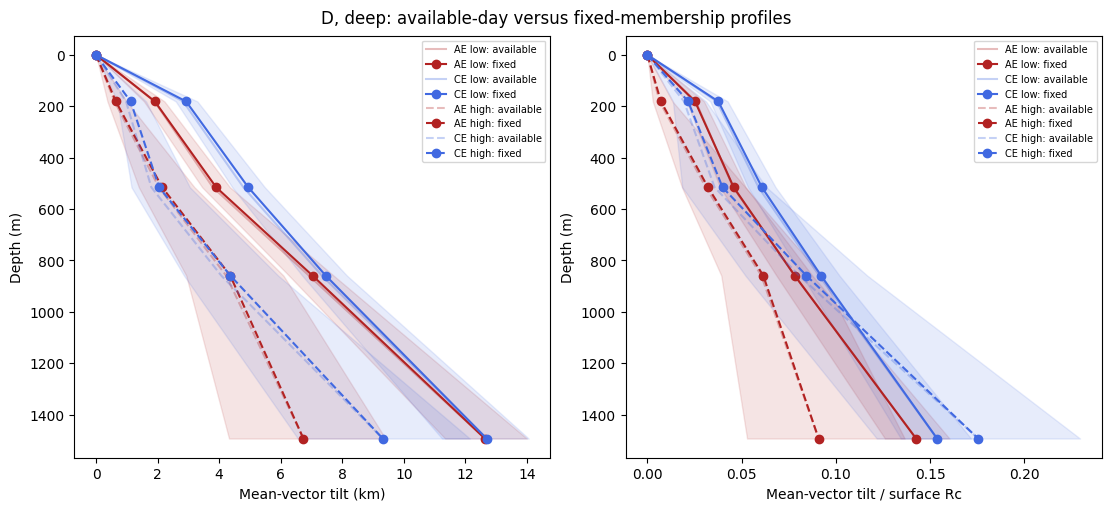

In [10]:
matched_results,matched_audit=rct.fixed_membership(regional_results,depth_map,
    MATCH_SHALLOW_TARGETS_M,MATCH_DEEP_TARGETS_M,n_boot=BOOTSTRAPS,seed=SEED)
display(matched_audit)
matched_centre_stats=rct.table(matched_results)
matched_normalised_stats=rct.table(matched_results,'normalised_stats')
fig,axs=plt.subplots(1,2,figsize=(11,5),constrained_layout=True)
for ro in ['low','high']:
    for cyc in ['AE','CE']:
        key=(FOCUS_REGION,FOCUS_COHORT,ro,cyc)
        if key not in matched_results:continue
        m=matched_results[key]
        for ax,field,col in [(axs[0],'stats','distance_km'),(axs[1],'normalised_stats','distance_Rc')]:
            s=m[field];orig=regional_results[key][field]
            orig=orig.loc[orig.Depth.isin(s.Depth)]
            style='-' if ro=='low' else '--'
            ax.plot(orig[col],orig.Depth,style,color=rct.COLORS[cyc],alpha=.3,label=f'{cyc} {ro}: available')
            ax.plot(s[col],s.Depth,style+'o',color=rct.COLORS[cyc],label=f'{cyc} {ro}: fixed')
            lo,hi=('distance_ci_low','distance_ci_high') if col=='distance_km' else ('distance_Rc_ci_low','distance_Rc_ci_high')
            ax.fill_betweenx(s.Depth,s[lo],s[hi],color=rct.COLORS[cyc],alpha=.12)
for ax,label in zip(axs,['Mean-vector tilt (km)','Mean-vector tilt / surface Rc']):
    ax.set(xlabel=label,ylabel='Depth (m)');ax.invert_yaxis()
    if ax.lines:ax.legend(fontsize=7)
fig.suptitle(f'{FOCUS_REGION}, {FOCUS_COHORT}: available-day versus fixed-membership profiles')
plt.show()


## Environmental context, without additional splits
PV regime, shelf longitude class, radius, water depth and available 0–200/0–500 m stratification summaries use the actual contributing days. PV fractions use the same dominance factor as before, **without** the extra shallow/deep-water regime filters from the planetary/topographic notebooks. N2 is descriptive and coverage-qualified; missing N2 does not remove days. These population summaries help identify possible confounding and are not controlled causal comparisons.


In [11]:
population_context=rct.population_context(profile_audit,regional_results)
with pd.option_context('display.max_rows',None):display(population_context)


,Region,cohort,Ro_class,Cyc,eddy_days,eddies,Ro_abs_median,Ro_abs_available_days,surface_Rc_km_median,surface_Rc_km_available_days,h_median,h_available_days,N2_200m_s2_median,N2_200m_s2_available_days,N2_500m_s2_median,N2_500m_s2_available_days,PV_planetary_fraction,PV_topographic_fraction,PV_mixed_fraction,PV_unknown_fraction,On-shelf_fraction,Off-shelf_fraction,Unknown_fraction
0,D,all,all,CE,24362,791,0.215095,24362,72.084170,24362,4657.343177,24362,0.000043,24362,0.000027,24362,0.074132,0.526517,0.399351,0.0,0.469830,0.530170,0.0
1,D,deep,all,CE,18527,735,0.218424,18527,78.051298,18527,4659.638836,18527,0.000043,18527,0.000028,18527,0.082744,0.503427,0.413828,0.0,0.495655,0.504345,0.0
2,D,deep,low,CE,17677,717,0.212183,17677,79.596293,17677,4655.887048,17677,0.000042,17677,0.000027,17677,0.081688,0.505912,0.412400,0.0,0.480681,0.519319,0.0
3,D,all,all,AE,34502,880,0.264974,34502,77.491786,34502,4661.402132,34502,0.000026,34502,0.000026,34502,0.160454,0.384239,0.455307,0.0,0.473132,0.526868,0.0
4,D,deep,all,AE,24613,792,0.280487,24613,87.484716,24613,4675.871252,24613,0.000024,24613,0.000026,24613,0.184008,0.351278,0.464714,0.0,0.516719,0.483281,0.0
5,D,deep,low,AE,22084,781,0.260964,22084,88.414659,22084,4667.612791,22084,0.000024,22084,0.000026,22084,0.166727,0.379234,0.454039,0.0,0.470884,0.529116,0.0
6,S,all,all,AE,8407,401,0.417382,8407,69.432504,8407,4419.408563,8407,0.000025,8407,0.000028,8407,0.023314,0.866064,0.110622,0.0,0.862614,0.137386,0.0
7,S,deep,all,AE,4435,305,0.452805,4435,84.227709,4435,4568.381922,4435,0.000021,4435,0.000028,4435,0.020293,0.837655,0.142052,0.0,0.835175,0.164825,0.0
8,S,deep,low,AE,2661,270,0.364846,2661,96.033308,2661,4544.241271,2661,0.000023,2661,0.000029,2661,0.016535,0.875611,0.107854,0.0,0.791056,0.208944,0.0
9,D,shallow,all,CE,5835,647,0.204263,5835,55.111934,5835,4647.521961,5835,0.000040,5835,0.000026,5835,0.046787,0.599829,0.353385,0.0,0.387832,0.612168,0.0


## Full ESP fits to the regional composites
Fit each detailed composite velocity field, using the existing DOPPIO inner + ESP outer procedure. `w`, `Omega` and `Rc` describe the **composite fit**, not averages of member parameters. The plots retain the current absolute-|w|/|Omega| style. Signed parameters, full-fit central vorticity and fit quality remain in the table.

Fits are attempted for all nonempty detailed groups. Failures/unsupported levels leave gaps. Parameter curves do not have confidence bands: the centre bootstrap does not quantify ESP-refit uncertainty. `FIT_REGIONS` can limit fitting for an exploratory run, but defaults to all three. `FIT_PLOT_REGIONS` controls only which figures are displayed.


,population,cohort,Cyc,status,successful_depths,attempted_depths
0,S | low Ro,deep,AE,attempted,30,30
1,S | low Ro,shallow,CE,attempted,22,22
2,S | low Ro,shallow,AE,attempted,22,22
3,S | low Ro,deep,CE,attempted,30,30
4,S | high Ro,deep,CE,attempted,30,30
5,S | high Ro,shallow,CE,attempted,22,22
6,S | high Ro,deep,AE,attempted,30,30
7,S | high Ro,shallow,AE,attempted,22,22
8,U | low Ro,deep,AE,attempted,30,30
9,U | low Ro,shallow,AE,attempted,22,22


,xc,yc,w,q11,q12,q22,Omega0,Omega,Rc,psi0,R,rho_limit_km,vector_rmse_ms,vector_nrmse,vector_r2,domain_rmse_ms,domain_nrmse,domain_r2,w_full_fit,psi0_raw_km_ms,n_outer_points,outer_min_days,n_boundary_radii,Depth,status,inner_ok,fit_ok,seed_xc,seed_yc,reason,xc_from_fit_reference,yc_from_fit_reference,n_eddy_days,n_eddies,fit_eligible,population,cohort,Cyc
0,-2.131115e-18,-1.803620e-16,0.000027,1.212170,0.115594,0.835990,0.000013,0.000012,94.034028,-51194.294090,65.000000,113.750000,0.025336,0.062257,0.996124,0.047636,0.196327,0.961456,0.000024,-51.194294,409,2661,4,0.000000,ok,True,True,0.000000e+00,0.000000e+00,,0.000000,0.000000,2661,270,True,S | low Ro,deep,AE
1,4.083999e-01,-4.901420e-01,0.000027,1.209332,0.113480,0.837551,0.000013,0.000011,99.355687,-56563.912189,65.001597,113.752794,0.026558,0.061145,0.996261,0.084255,0.296896,0.911852,0.000023,-56.563912,409,2661,4,5.879627,ok,True,True,-2.131115e-18,-1.803620e-16,,0.408400,-0.490142,2661,270,True,S | low Ro,deep,AE
2,6.229212e-01,-7.923283e-01,0.000027,1.206534,0.113896,0.839572,0.000013,0.000011,99.062936,-56278.527643,65.004002,113.757003,0.026438,0.061076,0.996270,0.082827,0.293948,0.913594,0.000023,-56.278528,409,2661,4,10.725783,ok,True,True,4.083999e-01,-4.901420e-01,,0.622921,-0.792328,2661,270,True,S | low Ro,deep,AE
3,7.706883e-01,-1.043841e+00,0.000027,1.204606,0.113806,0.840899,0.000013,0.000011,98.759172,-55813.518264,65.006662,113.761659,0.026147,0.060770,0.996307,0.080942,0.290301,0.915725,0.000023,-55.813518,408,2661,4,16.383097,ok,True,True,6.229212e-01,-7.923283e-01,,0.770688,-1.043841,2661,270,True,S | low Ro,deep,AE
4,9.556578e-01,-1.276766e+00,0.000027,1.205742,0.113639,0.840075,0.000013,0.000011,98.353169,-55471.563986,65.010056,113.767598,0.026026,0.060721,0.996313,0.075659,0.275411,0.924148,0.000023,-55.471564,409,2661,4,22.925581,ok,True,True,7.706883e-01,-1.043841e+00,,0.955658,-1.276766,2661,270,True,S | low Ro,deep,AE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,3.538386e+00,2.344717e-01,0.000014,0.948004,0.092646,1.063902,0.000007,0.000006,72.630579,-16524.260415,50.062800,87.609901,0.011132,0.066125,0.995627,0.031004,0.369775,0.863199,0.000013,-16.524260,243,330,4,327.440851,ok,True,True,2.451225e+00,-1.805998e-01,,3.538386,0.234472,330,85,True,D | high Ro,shallow,AE
620,4.682552e+00,1.775171e-01,0.000011,0.935851,0.134837,1.087973,0.000006,0.000005,79.014173,-16020.416437,52.609537,92.066689,0.008808,0.057699,0.996670,0.025990,0.324474,0.894684,0.000010,-16.020416,265,257,4,407.922192,ok,True,True,3.538386e+00,2.344717e-01,,4.682552,0.177517,257,77,True,D | high Ro,shallow,AE
621,6.644850e+00,-5.825204e-01,0.000009,0.942829,0.165327,1.089628,0.000004,0.000004,92.816028,-16116.613342,62.548178,109.459312,0.010649,0.081387,0.993373,0.046828,0.507572,0.742116,0.000008,-16.116613,376,199,4,515.416489,ok,True,True,4.682552e+00,1.775171e-01,,6.644850,-0.582520,199,66,True,D | high Ro,shallow,AE
622,7.012496e+00,-1.582230e+00,0.000007,0.941187,0.136004,1.082141,0.000003,0.000003,93.286798,-12489.036654,62.546827,109.456948,0.007802,0.077741,0.993951,0.021538,0.340244,0.884164,0.000006,-12.489037,377,137,4,660.806374,ok,True,True,6.644850e+00,-5.825204e-01,,7.012496,-1.582230,137,48,True,D | high Ro,shallow,AE


,population,cohort,Cyc,Depth,reason


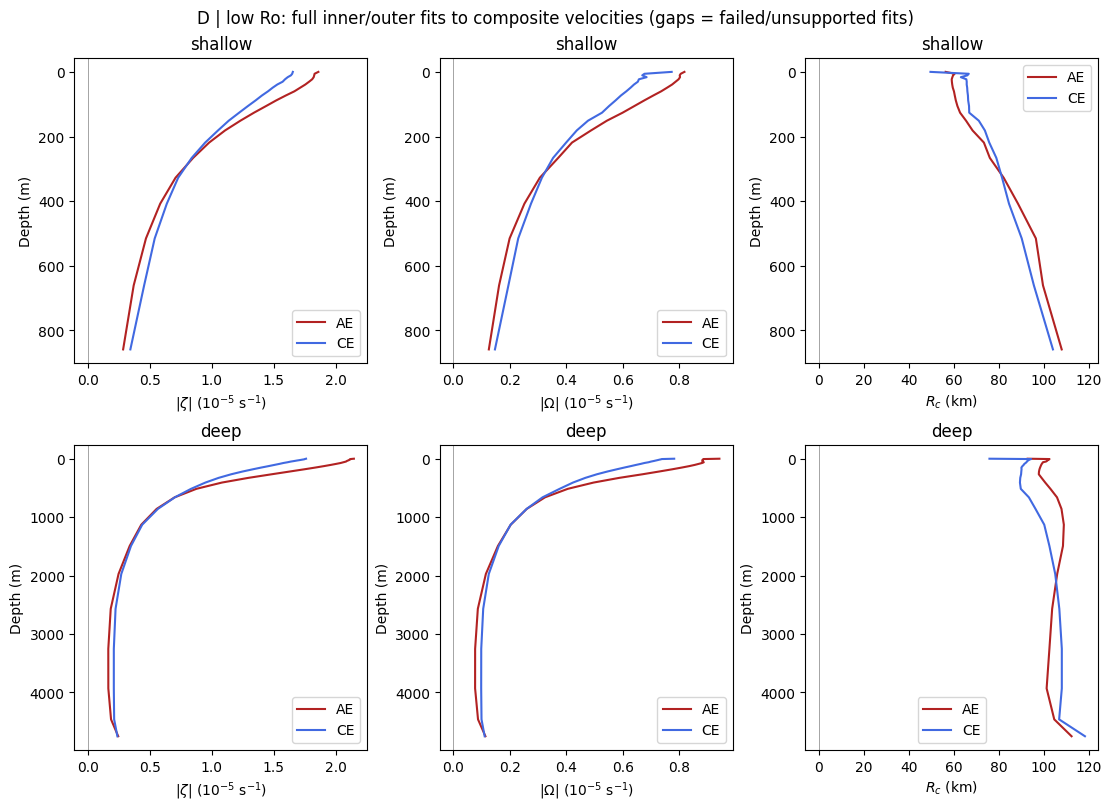

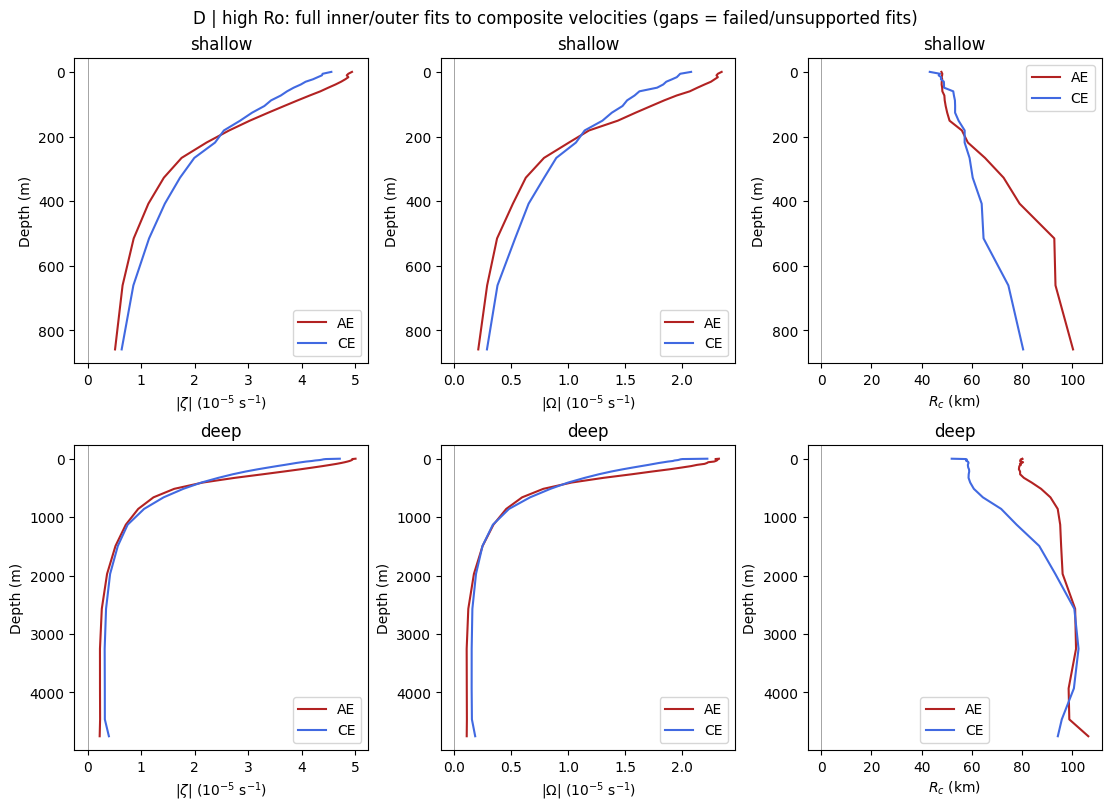

In [12]:
FIT_REGIONS=REGION_GROUPS
FIT_PLOT_REGIONS=[FOCUS_REGION]  # set to REGION_GROUPS to show all six populations of populations
comparison_sets=rct.comparison_sets(regional_results,FIT_REGIONS)
composite_esp_fits=pd.DataFrame();composite_fit_audit=pd.DataFrame()
if RUN_COMPOSITE_FITS:
    composite_esp_fits,composite_fit_audit=ccomp.fit_collections(comparison_sets,X,Y,esp,
        min_eddies=MIN_PLOT_EDDIES,transect_radius_km=30.,rho_min_km=30.,rho_max_km=200.,
        out_core_fac=1.75,max_jump_km=100.,min_cell_days=1)
    display(composite_fit_audit)
    if not composite_esp_fits.empty:
        display(composite_esp_fits)
        display(composite_esp_fits.loc[~composite_esp_fits.fit_ok,['population','cohort','Cyc','Depth','reason']])
        for region in FIT_PLOT_REGIONS:
            for ro in ['low','high']:
                label=f'{region} | {ro} Ro'
                if composite_esp_fits.population.eq(label).any():
                    ccomp.plot_fit_profiles(composite_esp_fits,label);plt.show()
else:print('Full composite ESP fits skipped')


## Horizontal and geographic vertical sections
Use the focus region/cohort/Rossby controls above. The horizontal maps use native model-grid axes and share an AE/CE speed scale. The two vertical cuts are geographic **zonal (meridional velocity)** and **meridional (zonal velocity)** through the surface centre. Sampling locations and velocities are rotated together; interpolation is horizontal only. Cuts do not follow a deeper centre that moves away from the surface reference.

The controls select visualisations only: all nonempty populations have already been reconstructed. Missing depths/groups remain labelled, not replaced with a neighbouring population or depth.


,target_m,Depth,status
0,500.0,515.416489,ok


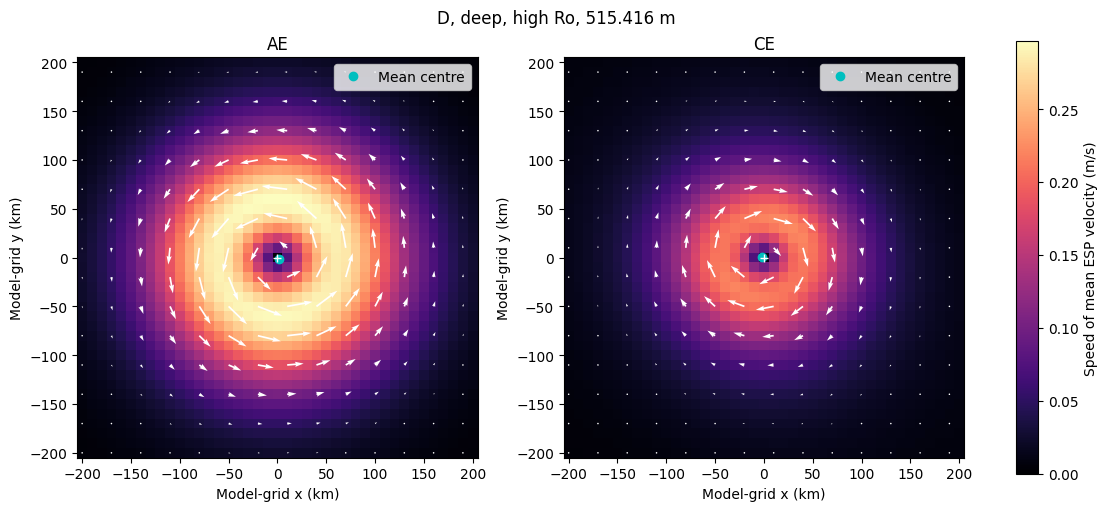

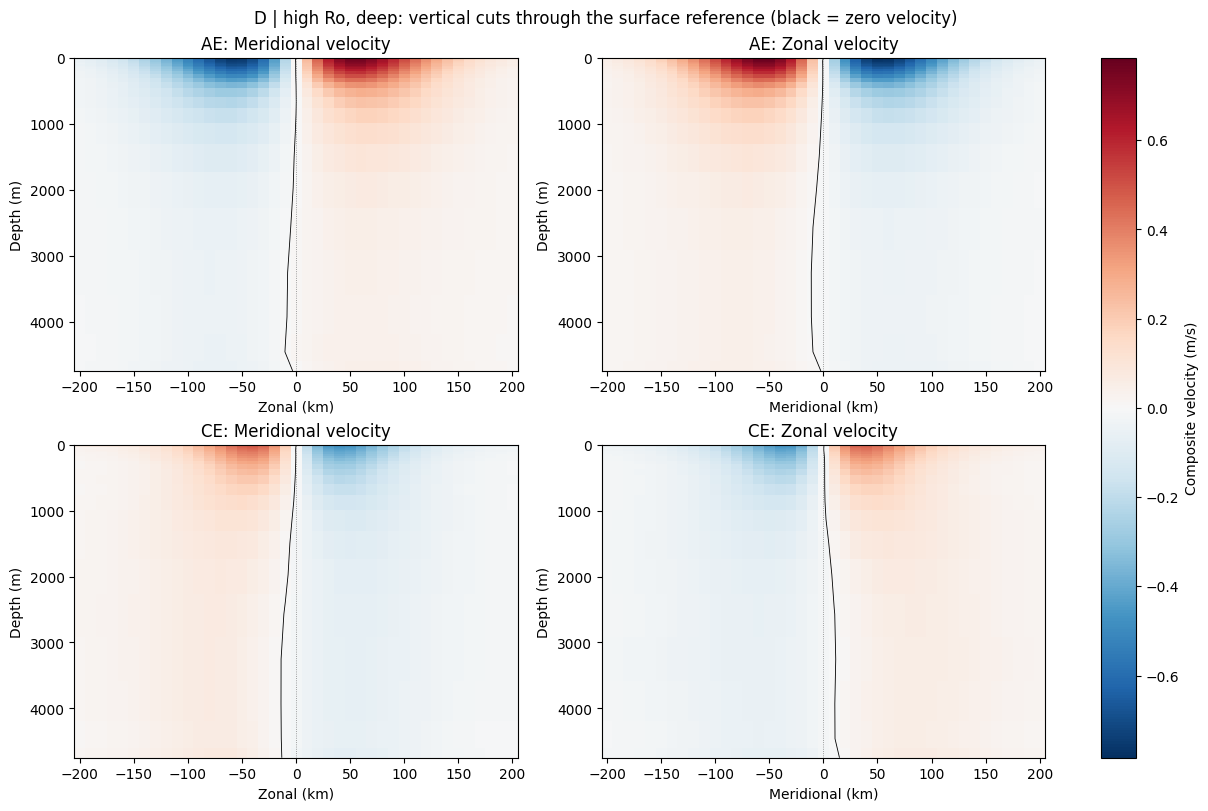

In [13]:
MAP_TARGET_DEPTH_M=500.
map_depth_map=rct.resolve_depths(centred_profiles.Depth.unique(),[MAP_TARGET_DEPTH_M],DEPTH_TOLERANCE_M)
display(map_depth_map)
map_depth=float(map_depth_map.Depth.iloc[0])
fig=rct.horizontal_maps(regional_results,X,Y,FOCUS_REGION,FOCUS_COHORT,FOCUS_RO_CLASS,map_depth)
if fig is not None:plt.show()
else:print('No horizontal velocity map for this exact depth/group; check support and reconstruction mode.')
section_results={(cohort,cyc):r for (region,cohort,ro,cyc),r in regional_results.items()
    if region==FOCUS_REGION and ro==FOCUS_RO_CLASS}
fig=ccomp.plot_sections(section_results,X,Y,f'{FOCUS_REGION} | {FOCUS_RO_CLASS} Ro',FOCUS_COHORT,
    rotation_rad=grid.angle,frame='geographic',min_eddies=MIN_PLOT_EDDIES)
if fig is not None:plt.show()
else:print('No reconstructed velocity sections for this group.')


## Optional output tables
The 42-slot inventory, input/reconstruction audits, depth support, physical and normalised statistics, matched checks, environmental context and full ESP fits remain available as named dataframes. `regional_results` retains member centres and velocity arrays. Exports below overwrite only the regional tables/settings in their own directory; no pickle cache or raw velocity volume is written.


In [14]:
SAVE_TABLES=False
if SAVE_TABLES:
    out=Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/regional_composite_tilt')
    out.mkdir(parents=True,exist_ok=True)
    for name in ['population_inventory','contributor_inventory','reconstruction_audit','centre_stats',
                 'normalised_centre_stats','tilt_summary','depth_map','matched_audit','matched_centre_stats',
                 'matched_normalised_stats','population_context','composite_esp_fits','composite_fit_audit']:
        globals()[name].to_csv(out/f'{name}.csv',index=False)
    (out/'settings.json').write_text(json.dumps(dict(regions=REGION_GROUPS,region_group_map=rct.REGION_GROUP_MAP,split_depth_m=SPLIT_DEPTH_M,
        rossby_split=ROSSBY_SPLIT,rossby='absolute surface w/f; high includes equality',weighting='equal day',
        dominance_factor=DOMINANCE_FACTOR,shelf_lon=SHELF_LON,grid_angle_rad=float(grid.angle),
        bootstrap_draws=BOOTSTRAPS,seed=SEED,minimum_plot_eddies=MIN_PLOT_EDDIES,sparse_eddies=SPARSE_EDDIES,
        summary_target_m=SUMMARY_TARGET_DEPTH_M,depth_tolerance_m=DEPTH_TOLERANCE_M,
        match_shallow_targets_m=MATCH_SHALLOW_TARGETS_M,match_deep_targets_m=MATCH_DEEP_TARGETS_M,
        width_km=WIDTH_KM,resolution_km=RES_KM,velocity=RUN_VELOCITY_COMPOSITES,
        fit_regions=FIT_REGIONS,fit_enabled=RUN_COMPOSITE_FITS,n2_cache=str(N2_CACHE),
        n2_min_valid_fraction=MIN_N2_CORE_VALID_FRACTION),indent=2))
    print(out)
